# Occupancy calculation for islet TMT PSMs

## Utility

#### Imports

In [111]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from dataclasses import dataclass
import limma_py
from adjustText import adjust_text


#### Utility functions

In [112]:
insignificant_mods = ["Multiplex Label", "Common Variable", "Common Fixed", "Metal", "Artifact"]
def remove_mods(sequence):
    for mod in insignificant_mods:
        sequence = re.sub(rf"\[{mod}.*?\]", "", sequence)
    return sequence

def parse_modifications(full_sequence):
    mod_pattern = re.compile(r"\[([^:\]]+):\s*([^\]]+)\]")
    posmods = {}
    base_position = 0
    i = 0

    while i < len(full_sequence):
        if full_sequence[i] == "[":
            mod_match = mod_pattern.match(full_sequence, i)
            if mod_match:
                mod_class = mod_match.group(1).strip()
                mod_name = mod_match.group(2).strip()

                # Skip insignificant annotations
                if mod_class not in insignificant_mods and mod_name not in insignificant_mods:
                    posmods.setdefault(base_position, []).append(mod_name)

                i = mod_match.end()
                continue

        # Count only sequence characters (not bracketed mods)
        base_position += 1
        i += 1

    return posmods

@dataclass
class Span:
    start: int
    end: int

def stringToSpan(span_string):
    start, end = re.match(r"\[(\d+) to (\d+)\]", span_string).groups()
    start, end = int(start), int(end)
    return Span(start, end)

def universal_phosphoserine(mod_name):
    if mod_name in ["Phosphorylation on S", "Phosphoserine on S"]:
        return "Phosphoserine on S"

class SiteModification:
    def __init__(self, mod_name: str, parent_position: int, parent_accession: str, parent_gene: str):
        self.modification_name = mod_name
        self.parent_position = parent_position
        self.parent_accession = parent_accession
        self.parent_gene = parent_gene
        self.mod_intensity: np.ndarray = np.zeros(18)
        self.total_intensity: np.ndarray = np.zeros(18)
        self.number_of_psms = 0

    def calculate_occupancy(self):
        if np.any(self.total_intensity > 0):
            return self.mod_intensity / self.total_intensity
        else:
            return np.zeros_like(self.mod_intensity)
        
def protein_position_intensity_lookup_map(row: pd.Series, start_col: int, end_column: int, global_lookup: dict):
    span = stringToSpan(row["Start and End Residues In Full Sequence"])
    if span.start == 1: # if the peptide starts at the protein N-terminus, then we want to include position 0 as the protein N-terminus. 
        span = Span(0, span.end)

    for pos in range(span.start, span.end + 1):
        key = (pos, row["Accession"])
        if key not in global_lookup:
            global_lookup[key] = np.zeros(end_column - start_col + 1)
        global_lookup[key] += row.iloc[start_col:end_column+1].to_numpy(dtype=np.float64)

def populate_site_modification_intensities(row: pd.Series, global_site_mods_dict: dict, global_totals_lookup: dict, start_col: int, end_col: int):
    # get the mods and their positions in the peptide
    posmods = parse_modifications(row["Full Sequence"])

    # map the peptide positions to protein positions.
    span = stringToSpan(row["Start and End Residues In Full Sequence"])
    
    for pos, mod in posmods.items():
        for m in mod:
            # if the modification is on the peptide N-terminus (pos=0) but the peptide doesn't 
            # start at the protein N-terminus (span.start != 1), then skip it since it's not a
            # protein N-terminal modification. 
            if (pos == 0 and span.start != 1):
                continue 
            
            # For now, we will treat phosphoserine and phosphorylation on S as the same modification 
            # since we know from our data that all the phosphoserines are phosphorylations.
            m = universal_phosphoserine(m) or m

            pos_in_protein = span.start + pos - 1
            
            if (m, pos_in_protein, row["Accession"]) not in global_site_mods_dict:
                global_site_mods_dict[(m, pos_in_protein, row["Accession"])] = SiteModification(m, pos_in_protein, row["Accession"], row["Gene Name"])
                global_site_mods_dict[(m, pos_in_protein, row["Accession"])].total_intensity = global_totals_lookup[(pos_in_protein, row["Accession"])]
                
            site_mod = global_site_mods_dict[(m, pos_in_protein, row["Accession"])]
            site_mod.mod_intensity += row.iloc[start_col:end_col+1].to_numpy(dtype=np.float64)
            global_site_mods_dict[(m, pos_in_protein, row["Accession"])].number_of_psms += 1

def visualize_coverage(dict_span_strings):
    _, ax = plt.subplots(figsize=(10, 5))
    cmaps = plt.get_cmap("tab20")
    colors = [cmaps(i) for i in range(len(dict_span_strings))]

    for i, k in enumerate(dict_span_strings.keys()):
        for ind, span_string in enumerate(sorted(dict_span_strings[k])):
            span = stringToSpan(span_string)
            ax.hlines(ind*0.4 + 0.1*i, span.start, span.end, colors=colors[i], linewidth=5, label=k if ind == 0 else "")

    ax.set_xlabel("Position in Protein")
    ax.set_ylabel("Peptides")
    ax.set_title("Peptide Coverage Across Protein")
    ax.legend()
    plt.show()

def logit(p, eps=1e-3):
    """Logit transform with epsilon clipping."""
    p = np.clip(p, eps, 1 - eps)
    return np.log2(p / (1 - p))

def inv_logit(log_odds):
    """Inverse logit transform."""
    odds = 2 ** log_odds
    return odds / (1 + odds)


## Data analysis and preprocessing

#### Import the data and visualize it

In [113]:
# Open the PSMs data
# Note TMT columns go as "undrugged" "drugged" "undrugged" "drugged" etc. so we can use that to determine which columns to use for occupancy calculations
filepath = r"C:\Users\student\Desktop\Islets\\AllPSMs_MS1Quant.tsv"
run_suffix = "MS1Quant_MS2Columns"
psms_data = pd.read_csv(filepath, sep="\t")
print(psms_data.shape)
psms_data.head()


(74450, 51)


,File Name,Scan Number,Precursor Charge,Base Sequence,Full Sequence,Ambiguity Level,Accession,Gene Name,Organism Name,QValue,...,MS1_intensity_130C,MS1_intensity_131N,MS1_intensity_131C,MS1_intensity_132N,MS1_intensity_132C,MS1_intensity_133N,MS1_intensity_133C,MS1_intensity_134N,MS1_intensity_134C,MS1_intensity_135N
0,02-22-26_Rep2_Frxn6_IsletDrugStudy_3uL,8270,2,QIPGGGSGGGGSGSGGGGGGSGGGR,[Multiplex Label:TMT18 on X]QIPGGGSGGGGSGSGGGG...,1,Q8BMA6,primary:Srp68,Mus musculus,0.000024,...,4880000.0,3810000.0,4570000.0,4460000.0,5150000.0,4640000.0,4710000.0,3700000.0,4570000.0,3890000.0
1,02-22-26_Rep2_Frxn5_IsletDrugStudy_5uL,3346,2,SGGGGGSSGAGGGPSCGTSSSR,[Multiplex Label:TMT18 on X]SGGGGGSSGAGGGPSC[C...,1,Q9CYN2,"primary:Spcs2, synonym:Spc25",Mus musculus,0.000024,...,15700000.0,12200000.0,10800000.0,13800000.0,13500000.0,14100000.0,12700000.0,13300000.0,13500000.0,13400000.0
2,02-22-26_Rep2_Frxn6_IsletDrugStudy_3uL,21751,2,AAGGAGAQVGGSISSGSSASSVTVTR,[Multiplex Label:TMT18 on X]AAGGAGAQVGGSISSGSS...,1,P48678,"primary:Lmna, synonym:Lmn1",Mus musculus,0.000024,...,3030000.0,2320000.0,2280000.0,2860000.0,2890000.0,2370000.0,3100000.0,2580000.0,2850000.0,2650000.0
3,02-22-26_Rep2_Frxn6_IsletDrugStudy_3uL,19385,2,NMGGPYGGGNYGPGGSGGSGGYGGR,[Multiplex Label:TMT18 on X]NMGGPYGGGNYGPGGSGG...,1,O88569,"primary:Hnrnpa2b1, synonym:Hnrpa2b1",Mus musculus,0.000024,...,1900000.0,1610000.0,1650000.0,1780000.0,1620000.0,2190000.0,1780000.0,1760000.0,1620000.0,1900000.0
4,02-22-26_Rep2_Frxn6_IsletDrugStudy_3uL,22483,2,LSTLGSGGESGGDGSPGGAGATAAR,[Multiplex Label:TMT18 on X]LSTLGSGGESGGDGSPGG...,1,Q80UU9,primary:Pgrmc2,Mus musculus,0.000024,...,8430000.0,7560000.0,5760000.0,8580000.0,7940000.0,8100000.0,7830000.0,8560000.0,7630000.0,7170000.0


In [114]:
psms_data.columns

Index(['File Name', 'Scan Number', 'Precursor Charge', 'Base Sequence',
       'Full Sequence', 'Ambiguity Level', 'Accession', 'Gene Name',
       'Organism Name', 'QValue', 'PEP', 'Decoy/Contaminant/Target',
       'MS2_intensity_126', 'MS2_intensity_127N', 'MS2_intensity_127C',
       'MS2_intensity_128N', 'MS2_intensity_128C', 'MS2_intensity_129N',
       'MS2_intensity_129C', 'MS2_intensity_130N', 'MS2_intensity_130C',
       'MS2_intensity_131N', 'MS2_intensity_131C', 'MS2_intensity_132N',
       'MS2_intensity_132C', 'MS2_intensity_133N', 'MS2_intensity_133C',
       'MS2_intensity_134N', 'MS2_intensity_134C', 'MS2_intensity_135N',
       'Fraction_Column_Used', 'Peptide_Detection_Type', 'Peptide_Intensity',
       'MS1_intensity_126', 'MS1_intensity_127N', 'MS1_intensity_127C',
       'MS1_intensity_128N', 'MS1_intensity_128C', 'MS1_intensity_129N',
       'MS1_intensity_129C', 'MS1_intensity_130N', 'MS1_intensity_130C',
       'MS1_intensity_131N', 'MS1_intensity_131C', 'MS1_i

### Filter the data to keep 0.1% FDR PSMs and remove ambiguity affecting localization

In [115]:
filtered_psms = psms_data[(psms_data["QValue"] < 0.01) 
                          & (psms_data["Decoy/Contaminant/Target"] == "T")
                          & (psms_data["Ambiguity Level"].astype(str) == "1")]
filtered_psms.shape

(74450, 51)

### TMT channel normalization

#### Visualize number of missing values per channel

Average undrugged column zeros: 1762.0, Average drugged column zeros: 1910.6666666666667


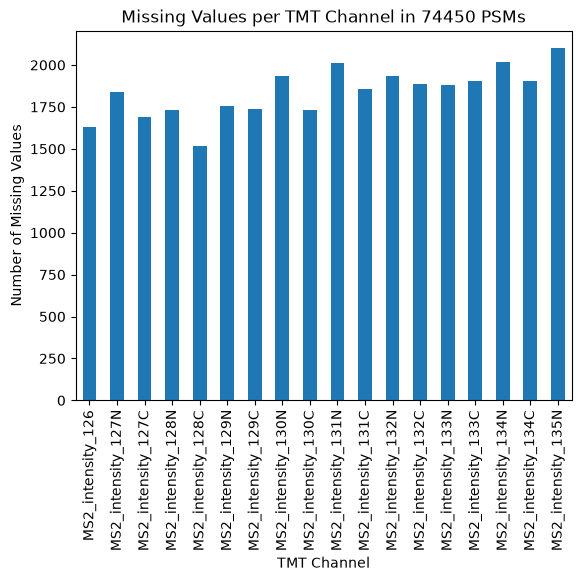

In [116]:
tmt1 = filtered_psms.columns.get_loc("MS2_intensity_126")
tmt18 = filtered_psms.columns.get_loc("MS2_intensity_135N")
counts_missing = (filtered_psms.iloc[:, tmt1:tmt18+1] == 0).sum(axis=0)
counts_missing.plot(kind="bar")
plt.xlabel("TMT Channel")
plt.ylabel("Number of Missing Values")
plt.title(f"Missing Values per TMT Channel in {filtered_psms.shape[0]} PSMs")

undrugged_zeros = (filtered_psms.iloc[:, tmt1:tmt18+1:2] == 0).sum(axis=0)
drugged_zeros = (filtered_psms.iloc[:, tmt1+1:tmt18+1:2] == 0).sum(axis=0)
avg_undrugged_zeros = undrugged_zeros.mean()
avg_drugged_zeros = drugged_zeros.mean()
print(f"Average undrugged column zeros: {avg_undrugged_zeros}, Average drugged column zeros: {avg_drugged_zeros}") # drugged samples have more zeros on average.

#### Remove PSMs with any missing channel intensity

In [117]:
filtered_psms = filtered_psms[~(filtered_psms.iloc[:, tmt1:tmt18+1] == 0).any(axis=1)]
print(f"Shape after removing rows with any zeros in TMT channels: {filtered_psms.shape}")

Shape after removing rows with any zeros in TMT channels: (70916, 51)


#### Visualize the distribution of TMT intensities across channels

Average undrugged intensities: 8210612018.78889. Average drugged intensities: 7885459799.422222


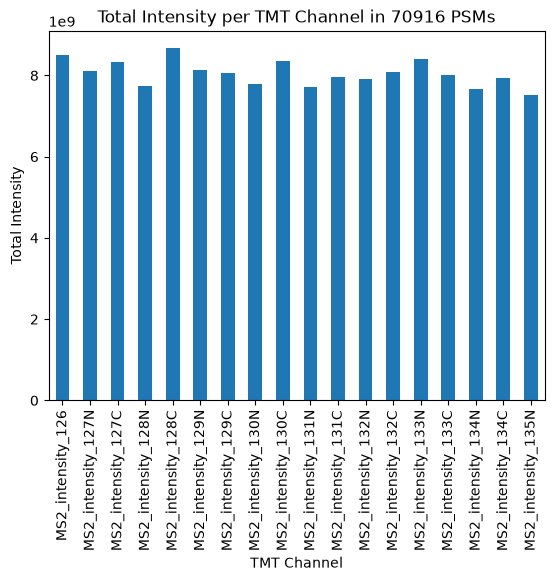

In [118]:
filtered_psms.iloc[:, tmt1:tmt18+1].sum().plot(kind="bar")
plt.xlabel("TMT Channel")
plt.ylabel("Total Intensity")
plt.title(f"Total Intensity per TMT Channel in {filtered_psms.shape[0]} PSMs")

undrugged_intensities = filtered_psms.iloc[:, tmt1:tmt18+1:2].sum().mean()
drugged_intensities = filtered_psms.iloc[:, tmt1+1:tmt18+1:2].sum().mean()
print(f"Average undrugged intensities: {undrugged_intensities}. Average drugged intensities: {drugged_intensities}")

#### Normalize the TMT intensities by the median of each channel

Text(0.5, 1.0, 'Total Intensity per TMT Channel after Median Normalization in 70916 PSMs')

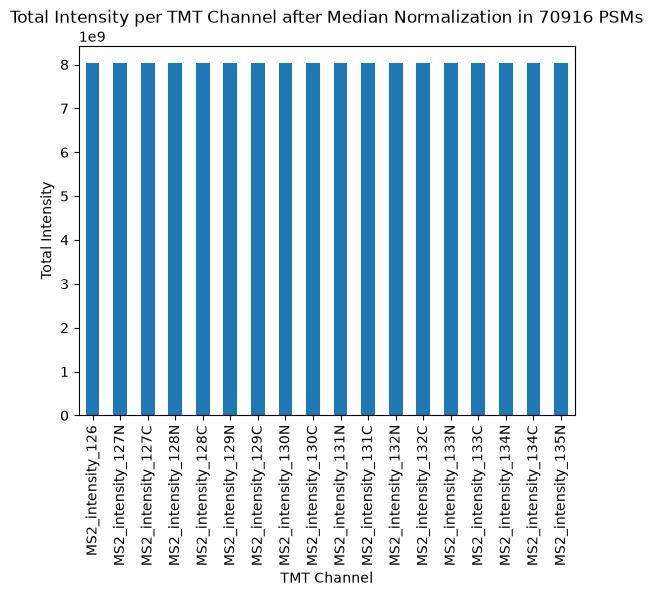

In [119]:
normalized_psms = filtered_psms.copy()

column_totals = normalized_psms.iloc[:, tmt1:tmt18+1].sum()
normalized_psms.iloc[:, tmt1:tmt18+1] = normalized_psms.iloc[:, tmt1:tmt18+1] * column_totals.median() / column_totals
normalized_psms.iloc[:, tmt1:tmt18+1].sum().plot(kind="bar")
plt.xlabel("TMT Channel")
plt.ylabel("Total Intensity")
plt.title(f"Total Intensity per TMT Channel after Median Normalization in {normalized_psms.shape[0]} PSMs")

#### Channel statistics after normalization

In [120]:
normalized_psms[psms_data.columns[tmt1:tmt18+1]].describe()

,MS2_intensity_126,MS2_intensity_127N,MS2_intensity_127C,MS2_intensity_128N,MS2_intensity_128C,MS2_intensity_129N,MS2_intensity_129C,MS2_intensity_130N,MS2_intensity_130C,MS2_intensity_131N,MS2_intensity_131C,MS2_intensity_132N,MS2_intensity_132C,MS2_intensity_133N,MS2_intensity_133C,MS2_intensity_134N,MS2_intensity_134C,MS2_intensity_135N
count,7.091600e+04,7.091600e+04,7.091600e+04,7.091600e+04,7.091600e+04,7.091600e+04,7.091600e+04,7.091600e+04,7.091600e+04,7.091600e+04,7.091600e+04,7.091600e+04,7.091600e+04,7.091600e+04,7.091600e+04,7.091600e+04,7.091600e+04,7.091600e+04
mean,1.131755e+05,1.131755e+05,1.131755e+05,1.131755e+05,1.131755e+05,1.131755e+05,1.131755e+05,1.131755e+05,1.131755e+05,1.131755e+05,1.131755e+05,1.131755e+05,1.131755e+05,1.131755e+05,1.131755e+05,1.131755e+05,1.131755e+05,1.131755e+05
std,4.178647e+05,3.583089e+05,5.572911e+05,3.290135e+05,4.111825e+05,3.188468e+05,3.722681e+05,3.144193e+05,3.890261e+05,3.408797e+05,4.784928e+05,3.267646e+05,4.807832e+05,3.403043e+05,4.548464e+05,3.396370e+05,4.722225e+05,3.425844e+05
min,5.854137e+02,6.049600e+02,6.109874e+02,6.196322e+02,6.096019e+02,6.661098e+02,6.576860e+02,7.127512e+02,6.293040e+02,7.014977e+02,7.199960e+02,6.806738e+02,6.753485e+02,6.713181e+02,7.109609e+02,7.732538e+02,7.056978e+02,7.166994e+02
25%,1.627539e+04,1.599439e+04,1.644039e+04,1.667657e+04,1.632516e+04,1.606850e+04,1.625651e+04,1.622775e+04,1.639926e+04,1.622012e+04,1.649904e+04,1.616882e+04,1.618040e+04,1.603710e+04,1.623596e+04,1.617316e+04,1.642363e+04,1.627613e+04
50%,4.057402e+04,4.025596e+04,4.097161e+04,4.141188e+04,4.098818e+04,4.059449e+04,4.110468e+04,4.075263e+04,4.163438e+04,4.077841e+04,4.099456e+04,4.073260e+04,4.062651e+04,4.054810e+04,4.065493e+04,4.080022e+04,4.101126e+04,4.092219e+04
75%,1.017922e+05,1.013479e+05,1.019183e+05,1.036632e+05,1.027210e+05,1.022973e+05,1.035227e+05,1.021632e+05,1.040583e+05,1.021114e+05,1.019947e+05,1.017613e+05,1.013671e+05,1.010718e+05,1.013184e+05,1.019870e+05,1.017892e+05,1.021147e+05
max,5.621179e+07,3.601070e+07,8.789034e+07,3.072213e+07,5.334711e+07,2.250971e+07,4.477650e+07,2.316467e+07,4.987155e+07,3.397863e+07,7.129471e+07,2.730002e+07,7.182656e+07,3.289181e+07,6.698475e+07,3.322780e+07,7.331663e+07,3.417431e+07


### Data analysis for additional filtering

#### Number of base sequences and unmodified peptides

In [121]:
# Check how many unique base sequences we have and how many of them are identical to the full sequence 
# with modifications removed (i.e. no modifications or only insignificant modifications).
# This gives us an idea of the rows that are just unmodified peptides or peptides with only insignificant modifications, 
# which can be useful for an occupancy workflow where we try to account for IE. 
print(f" Number of unique base sequences: {normalized_psms['Base Sequence'].nunique()}")
print(f" Number of PSMs corresponding to unmodified peptides: {(normalized_psms['Base Sequence'] == normalized_psms['Full Sequence'].map(remove_mods)).sum()}")

 Number of unique base sequences: 34837
 Number of PSMs corresponding to unmodified peptides: 68650


#### Remove insignificant modifications (defined in the `insignificant_mods` list)

In [122]:
cleaned_sequences_psms = normalized_psms.copy()
cleaned_sequences_psms["Full Sequence"] = cleaned_sequences_psms["Full Sequence"].map(remove_mods)

#### Base sequence representation in peptides

In [123]:
# Rows per Base Sequence for groups where at least one row has Full Sequence == Base Sequence
eq_mask = cleaned_sequences_psms["Full Sequence"].eq(cleaned_sequences_psms["Base Sequence"])
group_has_exact_match = eq_mask.groupby(cleaned_sequences_psms["Base Sequence"]).transform("any")

rows_per_base_sequence = (
    cleaned_sequences_psms.loc[group_has_exact_match]
    .groupby("Base Sequence")
    .size()
    .sort_values(ascending=False)
)

print(rows_per_base_sequence)
print(f"Number of qualifying Base Sequence groups: {rows_per_base_sequence.shape[0]}")
print(f"Total rows in qualifying groups: {rows_per_base_sequence.sum()}")

Base Sequence
GFFYTPK                                  52
VVDLMAYMASKE                             49
DFPEEVAIAEELGR                           43
LYQSAGGMPGGMPGGFPGGGAPPSGGASSGPTIEEVD    43
QQQQQQQQQQQEQQHSSFEDELSEVFENQSPDAK       40
                                         ..
NEEDVGAGDQGLMFGYATDETEECMPLTIVLAHK        1
YYSDLFSYCDIESTKK                          1
YYPTAEEVYGPEVETIVQEEDTQPLTEPIIKPVK        1
YYPSGDAFASGSDDATCR                        1
YYPASPWVDNSR                              1
Length: 34111, dtype: int64
Number of qualifying Base Sequence groups: 34111
Total rows in qualifying groups: 69371


In [124]:
rows_per_base_sequence.value_counts()[1] # how many groups have only 1 row? This means we observed no modified forms for those base sequences.

np.int64(13382)

#### Protein group ambiguity analysis
One thing to consider is that PSMs can be shared by multiple proteins in a protein group, and some PSMs can match, and be unique to, any of the proteins in that protein group. We need to check if the shared and unique PSMs overlap along their base sequence. If they overlap, it makes it difficult to determine the occupancy of the shared PSMs. If they don't overlap, we can still use the shared PSMs for occupancy calculation.

In [125]:
needPosFromElsewhere = True
elsewherePath = r"C:\Users\student\Desktop\Islets\AllPSMs.psmtsv"

# I should do this with a df.join()
if needPosFromElsewhere and elsewherePath:
    elsewhereData = pd.read_csv(elsewherePath, sep='\t')
    #print(elsewhereData.columns)
    records = elsewhereData[["Accession", "Base Sequence", "Start and End Residues In Full Sequence"]].to_records()
    seqToPosMap = {(acc, seq): startend for _, acc, seq, startend in records}

    ordered = [seqToPosMap[(acc, seq)] 
               if (acc, seq) in seqToPosMap else pd.NA
               for _, acc, seq in cleaned_sequences_psms[["Accession", "Base Sequence"]].to_records()]
    cleaned_sequences_psms["Start and End Residues In Full Sequence"] = ordered
    cleaned_sequences_psms.dropna(subset="Start and End Residues In Full Sequence", inplace=True)
    print(cleaned_sequences_psms.shape)

C:\Users\student\AppData\Local\Temp\ipykernel_22784\4151890318.py:6: DtypeWarning: Columns (0: Num Variable Mods, 1: Missed Cleavages, 2: Monoisotopic Mass, 3: Mass Diff (Da), 4: Mass Diff (ppm)) have mixed types. Specify dtype option on import or set low_memory=False.
  elsewhereData = pd.read_csv(elsewherePath, sep='\t')


(70909, 52)


In [126]:
# Find protein group accessions that overlap with other accessions. 
# There is only one set of shared peptides represented in this dataset.
accessions = cleaned_sequences_psms["Accession"].unique()
overlap = [(acc1, acc2) for ind, acc1 in enumerate(accessions) for acc2 in accessions[:ind] if acc1 != acc2 and any(set(acc1.split("|")) & set(acc2.split("|")))]
overlap

[('Q61029|Q61033', 'Q61029'), ('Q61033', 'Q61029|Q61033')]

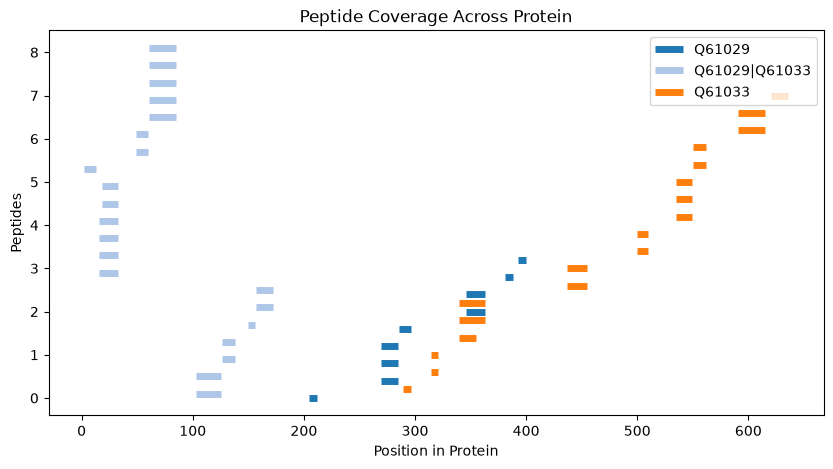

In [127]:
# For the overlapping accessions, visualize the coverage of the peptides along the protein sequence to see if the shared and unique peptides overlap in their coverage. 
# If they do, it may be difficult to determine the occupancy of the shared peptides. If they don't, we can still use the shared peptides for occupancy calculation.
# Here it seems like the shared peptides do not overlap with the unique peptides, which means we can still use the shared peptides for occupancy calculation without 
# worrying about ambiguity from the unique peptides. Nothing needs to be done to consolidate the protein groups...
ambiguous_pgs = set([acc for pair in overlap for acc in pair])
spans = cleaned_sequences_psms[cleaned_sequences_psms["Accession"].isin(ambiguous_pgs)].groupby("Accession")["Start and End Residues In Full Sequence"].apply(list)
visualize_coverage({ind: spans[ind] for ind in spans.index})

In [128]:
# In case it was considerable to drop the ambiguous protein groups, here are the stats for the TMT channels for the PSMs corresponding to the ambiguous protein groups
# to visualize their impact. 
cleaned_sequences_psms[cleaned_sequences_psms["Accession"].isin(ambiguous_pgs)][psms_data.columns[tmt1:tmt18+1]].describe()

,MS2_intensity_126,MS2_intensity_127N,MS2_intensity_127C,MS2_intensity_128N,MS2_intensity_128C,MS2_intensity_129N,MS2_intensity_129C,MS2_intensity_130N,MS2_intensity_130C,MS2_intensity_131N,MS2_intensity_131C,MS2_intensity_132N,MS2_intensity_132C,MS2_intensity_133N,MS2_intensity_133C,MS2_intensity_134N,MS2_intensity_134C,MS2_intensity_135N
count,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000
mean,89232.081327,89788.615455,91083.956719,99155.175597,91831.104358,90089.703244,91433.243359,85787.483574,94949.421336,87268.555859,88040.375878,84649.858746,89469.529580,83398.120082,87761.090909,85977.009140,87623.157804,85727.845820
std,116780.190839,119899.527410,117510.706958,120642.283238,119931.796781,117311.087580,118864.587884,114093.346055,121281.567163,114050.297848,111811.843284,107709.926109,117592.701662,108946.475474,114766.206738,113565.474432,116303.966850,113035.065095
min,6580.740868,6079.773639,6072.537400,5875.400580,6192.339840,5369.850045,7301.661153,5561.992408,6468.502836,5818.347074,5619.594309,6678.560202,5885.406566,5511.769331,5777.334574,7183.912174,7429.014892,5069.332009
25%,21646.538523,20265.392744,21432.821191,26139.320689,24219.379372,24036.548024,24854.373691,22170.342238,22052.087661,20819.523226,20193.799575,21373.914601,21009.119189,19029.229435,21077.509269,19653.821474,18708.617344,21539.081014
50%,37285.866221,37275.378583,37841.614531,44590.531091,44251.288490,40037.868891,39900.599417,34083.006951,41256.452406,36627.977630,39347.632834,37693.721929,36296.502980,34420.519003,38191.937892,37358.366324,36464.219443,37571.559017
75%,84675.047488,83367.640840,91582.263261,92796.984722,81834.581901,83054.893386,79480.333817,79172.991381,92717.113135,78589.171643,86425.858173,84639.285061,88483.191407,79874.233857,81495.022934,77629.877377,83483.029714,78856.824502
max,466139.112532,485180.874876,452517.541229,401882.879827,482381.050763,473880.800622,458479.459302,458548.304536,472083.667455,446322.313763,413017.927301,420981.596666,467107.081427,446886.933186,468732.820685,448771.245275,459598.343123,447308.637957


#### Filter sequences with ambiguity issues.

In [129]:
# how many accessions map to more than one protein or position? This means we can't be sure which protein/position the modification is on.
ambiguity_mask = cleaned_sequences_psms[["Full Sequence", "Start and End Residues In Full Sequence"]].apply(lambda x: x.str.contains("|", regex=False))
print(ambiguity_mask.sum())

all_current_columns = cleaned_sequences_psms[psms_data.columns[tmt1:tmt18+1]]
columns_to_be_filtered = cleaned_sequences_psms[ambiguity_mask.sum(axis=1) > 0][psms_data.columns[tmt1:tmt18+1]]

pd.DataFrame({"max ratio": columns_to_be_filtered.max() / all_current_columns.max(),
              "sum fraction": columns_to_be_filtered.sum() / all_current_columns.sum(),
              "median to median ratio": columns_to_be_filtered.median() / all_current_columns.median(),
              "max to median ratio": columns_to_be_filtered.max() / all_current_columns.median()})

Full Sequence                               0
Start and End Residues In Full Sequence    62
dtype: int64


,max ratio,sum fraction,median to median ratio,max to median ratio
MS2_intensity_126,0.004448,0.000461,0.864088,6.162921
MS2_intensity_127N,0.005947,0.000433,0.893208,5.320140
MS2_intensity_127C,0.002271,0.000430,0.826692,4.872511
MS2_intensity_128N,0.007321,0.000466,0.950067,5.431154
MS2_intensity_128C,0.004387,0.000469,0.882962,5.710079
MS2_intensity_129N,0.009967,0.000466,0.979398,5.527010
MS2_intensity_129C,0.006277,0.000517,1.084500,6.837655
MS2_intensity_130N,0.011012,0.000493,1.010731,6.259673
MS2_intensity_130C,0.004540,0.000501,1.022196,5.438721
MS2_intensity_131N,0.006900,0.000459,0.895746,5.750494


In [130]:
# Since it's only 65 with ambiguity in position
# 61 with ambiguity in full sequence
# We can remove these ambiguous cases and proceed with occupancy calculations on the remaining data.
cleaned_sequences_psms = cleaned_sequences_psms[~cleaned_sequences_psms["Start and End Residues In Full Sequence"].str.contains("|", regex=False)]
cleaned_sequences_psms = cleaned_sequences_psms[~cleaned_sequences_psms["Full Sequence"].str.contains("|", regex=False)]

## Occupancy calculation

In [131]:
# check if there are any C-terminal modifications that we need to worry about during parsing.
cleaned_sequences_psms[cleaned_sequences_psms["Full Sequence"].str.contains(r"-\[")]["Full Sequence"]

Series([], Name: Full Sequence, dtype: str)

### Generate Site Modifications

In [132]:
# Calculate lookup table of position's total intensities for every protein position
# This will be used to calculate occupancy denominators for each site modification.
# key is (position, accession) and value is ndarray of total intensity across samples 
# at that position across all PSMs. 
protein_position_intensity = {} 
cleaned_sequences_psms.apply(
    lambda row: protein_position_intensity_lookup_map(row, tmt1, tmt18, protein_position_intensity), axis=1
)
print(f"Number of positions with intensity data: {len(protein_position_intensity)}")


Number of positions with intensity data: 469422


In [133]:
site_modifications = {}
cleaned_sequences_psms.apply(
    lambda row: populate_site_modification_intensities(row, site_modifications, protein_position_intensity, tmt1, tmt18), axis=1
)
print(f"Number of site modifications: {len(site_modifications)}")

Number of site modifications: 575


### Site modification visualization across channels

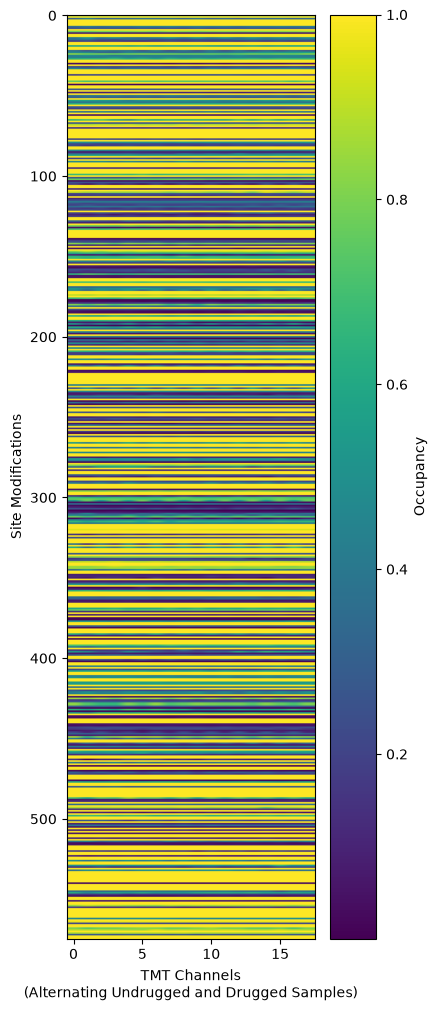

In [134]:
first = list(site_modifications.keys())[0]
all_sites_arr = np.array([site.calculate_occupancy() for site in site_modifications.values()])

fig, ax = plt.subplots(figsize=(4, 12))
im = ax.imshow(all_sites_arr, aspect="auto")
ax.set_xlabel("TMT Channels\n(Alternating Undrugged and Drugged Samples)")
ax.set_ylabel("Site Modifications")
plt.colorbar(im, ax=ax, label="Occupancy")
plt.show()

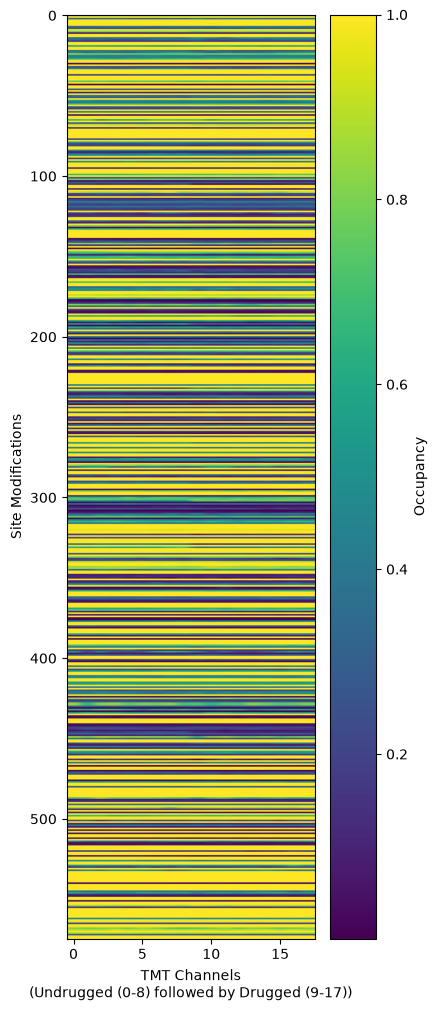

In [135]:
drugged_occupancies = all_sites_arr[:, 1::2]
undrugged_occupancies = all_sites_arr[:, 0::2]
occupancies_by_condition = np.concatenate((undrugged_occupancies, drugged_occupancies), axis=1)

fig, ax = plt.subplots(figsize=(4, 12))
im = ax.imshow(occupancies_by_condition, aspect="auto")
ax.set_xlabel("TMT Channels\n(Undrugged (0-8) followed by Drugged (9-17))")
ax.set_ylabel("Site Modifications")
plt.colorbar(im, label="Occupancy")
plt.show()

### Modifications identified

In [136]:
modifications_list = set(mod for mod, _, _ in site_modifications.keys())
for _ in sorted(modifications_list):
    print(_)

3-hydroxyproline on P
4-hydroxyproline on P
Acetylation on K
Acetylation on X
Asymmetric dimethylarginine on R
Cysteine persulfide on C
Cysteine sulfonic acid (-SO3H) on C
Deamidated asparagine on N
Dimethylated arginine on R
Hydroxylation on K
Hydroxylation on N
Hydroxylation on P
Methylation on R
N-acetylmethionine on M
N6,N6,N6-trimethyllysine on K
N6,N6-dimethyllysine on K
N6-acetyllysine on K
N6-succinyllysine on K
Omega-N-methylarginine on R
Phosphoserine on S
Phosphothreonine on T
Phosphotyrosine on Y


## Data Output for downstream analysis

### Filter Site Modifications

In [137]:
output_sites = [site for site in site_modifications.values() if  0 < site.calculate_occupancy().sum() < 18] # filter out unchanged sites

# Recreate a DataFrame with rows as site modifications and columns as TMT channels, with occupancy values as the entries. 
# Include columns for modification name, protein accession, and position for easier analysis.

total_mod_intensities_transposed = np.array([site.mod_intensity for site in output_sites]).T
total_intensities_transposed = np.array([site.total_intensity for site in output_sites]).T
occupancies_transposed = np.array([site.calculate_occupancy() for site in output_sites]).T
mean_sample_intensity_weighted_occupancies_transposed = occupancies_transposed * total_intensities_transposed.mean(axis=0, keepdims=True)

output_df = pd.DataFrame({
    "Modification": [site.modification_name for site in output_sites],
    "Position": [site.parent_position for site in output_sites],
    "Accession": [site.parent_accession for site in output_sites],
    "Gene Name": [site.parent_gene for site in output_sites],
    **{psms_data.columns[tmt1 + i] + " Mod Intensity": total_mod_intensities_transposed[i] for i in range(18)},
    **{psms_data.columns[tmt1 + i] + " Total Intensity": total_intensities_transposed[i] for i in range(18)},
    **{psms_data.columns[tmt1 + i] + " Mean Sample Intensity-Weighted Site Abundance": mean_sample_intensity_weighted_occupancies_transposed[i] for i in range(18)},
    **{psms_data.columns[tmt1 + i] + " Occupancy": occupancies_transposed[i] for i in range(18)}
})
print(f"Output DataFrame shape: {output_df.shape}")

Output DataFrame shape: (323, 76)


In [138]:
total_intensities_transposed.mean(axis=0, keepdims=True).shape

(1, 323)

In [139]:
if True:
    (output_df
     .sort_values(["Accession", "Position", "Modification"])
     .reset_index(drop=True)
     .to_csv(f"C:\\Users\\student\\Desktop\\Islets\\site_modification_occupancies_{run_suffix}.tsv", index=False, sep="\t")
    )


### Check the distribution of transformed occupancies for statistical analysis

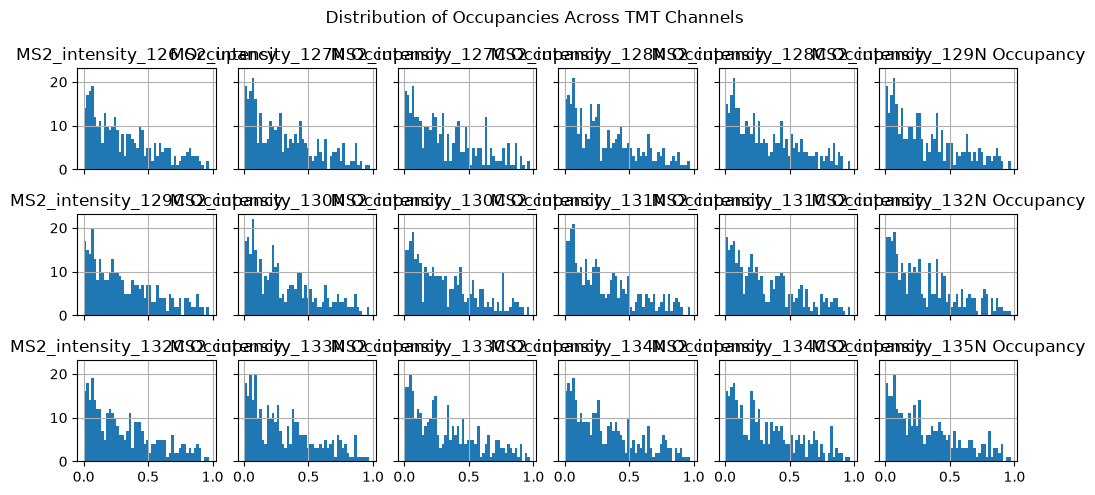

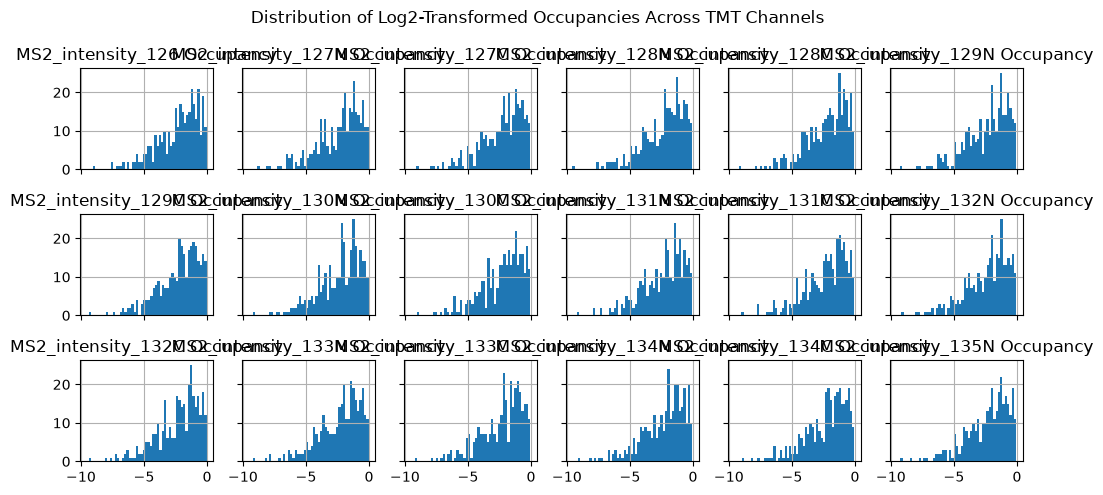

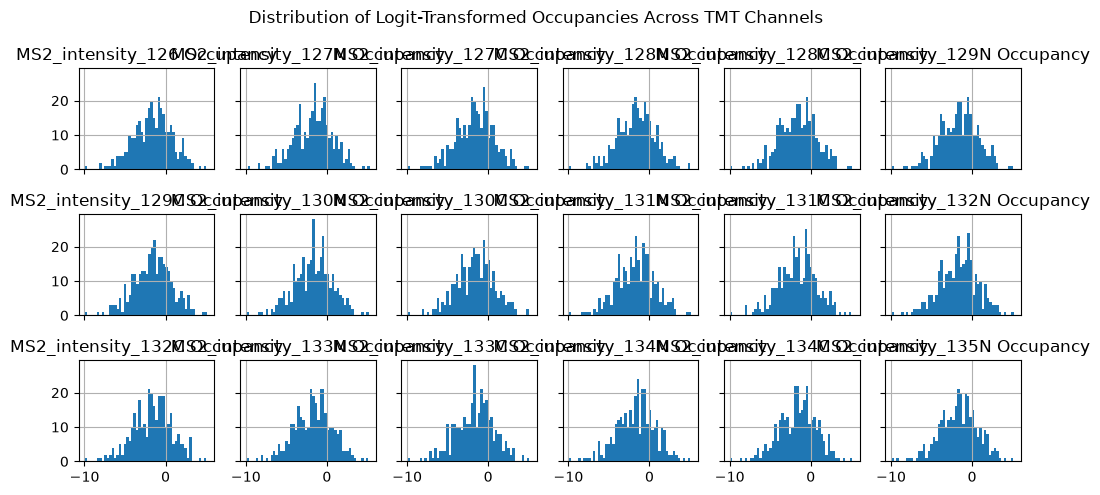

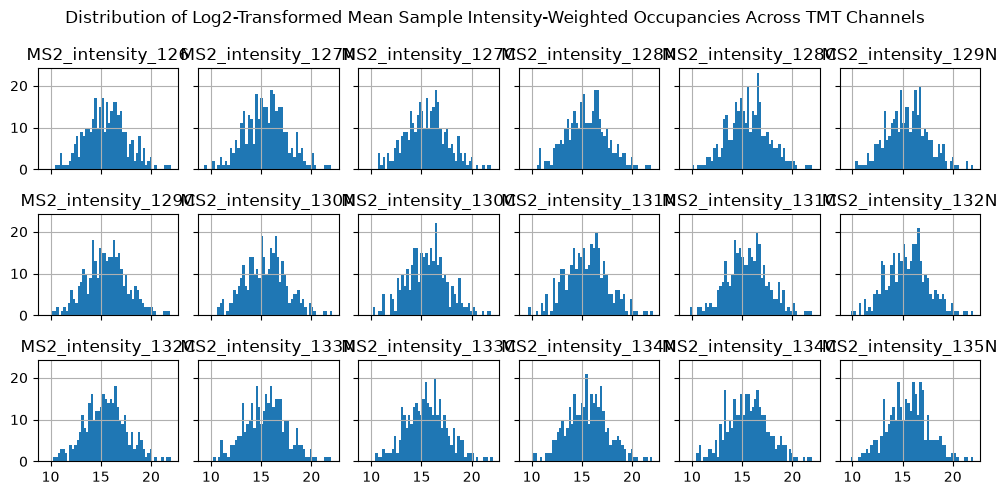

In [140]:
raw_occupancies = output_df.iloc[:, -18:]
raw_occupancies.hist(bins=50, figsize=(10, 5), layout=(3, 6), sharex=True, sharey=True)
plt.suptitle("Distribution of Occupancies Across TMT Channels")
plt.tight_layout()


log2_occupancies = np.log2(output_df.iloc[:, -18:] + 1e-3) # add small constant to avoid log(0)
log2_occupancies.hist(bins=50, figsize=(10, 5), layout=(3, 6), sharex=True, sharey=True)
plt.suptitle("Distribution of Log2-Transformed Occupancies Across TMT Channels")
plt.tight_layout()


logit_occupancies = logit(output_df.iloc[:, -18:])
logit_occupancies.hist(bins=50, figsize=(10, 5), layout=(3, 6), sharex=True, sharey=True)
plt.suptitle("Distribution of Logit-Transformed Occupancies Across TMT Channels")
plt.tight_layout()


log2_mean_weighted_occupancies = np.log2(output_df.iloc[:, -36:-18] + 1e-3) # add small constant to avoid log(0)
log2_mean_weighted_occupancies.columns = log2_mean_weighted_occupancies.columns.str.replace(" Mean Sample Intensity-Weighted Site Abundance", "")
log2_mean_weighted_occupancies.hist(bins=50, figsize=(10, 5), layout=(3, 6), sharex=True, sharey=True)
plt.suptitle("Distribution of Log2-Transformed Mean Sample Intensity-Weighted Occupancies Across TMT Channels")
plt.tight_layout()


plt.show()

In [141]:
log2_mean_weighted_occupancies

,MS2_intensity_126,MS2_intensity_127N,MS2_intensity_127C,MS2_intensity_128N,MS2_intensity_128C,MS2_intensity_129N,MS2_intensity_129C,MS2_intensity_130N,MS2_intensity_130C,MS2_intensity_131N,MS2_intensity_131C,MS2_intensity_132N,MS2_intensity_132C,MS2_intensity_133N,MS2_intensity_133C,MS2_intensity_134N,MS2_intensity_134C,MS2_intensity_135N
0,19.178004,19.128666,19.233235,19.261613,19.075496,19.124922,19.106200,19.083905,19.004929,19.131339,19.038828,19.144214,19.082568,19.116214,19.035051,19.113314,19.064195,19.122254
1,18.107646,18.576527,18.110205,18.219740,18.270889,18.398277,18.336894,18.369819,18.187703,18.401241,18.151075,18.256836,18.030272,18.254332,18.251017,18.303689,18.160348,18.264585
2,18.120474,18.322239,18.135217,18.277158,18.256918,18.416155,18.357000,18.445349,18.318254,18.399633,18.321797,18.367301,18.177654,18.324286,18.317002,18.403015,18.304388,18.311381
3,16.291240,16.445071,16.368627,16.309198,16.200815,16.366012,16.242913,16.315825,16.143910,16.455943,16.194555,16.334076,16.336295,16.423174,16.303056,16.380948,16.346411,16.486080
4,16.195414,16.160243,16.210793,16.204316,16.227955,16.258639,16.198236,16.266927,16.247164,16.213553,16.243273,16.255821,16.238244,16.256401,16.270894,16.261180,16.277967,16.301807
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
318,17.315890,17.323664,17.294760,17.374736,17.254691,17.375428,17.265864,17.314921,17.278944,17.166129,17.250632,17.218855,17.315811,17.306431,17.294069,17.315533,17.268019,17.353312
319,13.893700,13.769281,13.847554,13.842933,13.900361,13.938256,13.899539,13.827057,13.837572,13.901412,13.964376,13.862310,13.868574,13.792192,13.787527,13.841201,13.721212,13.891753
320,14.944269,14.925285,14.919539,14.922691,14.897761,14.882960,15.011654,14.918630,14.939942,14.937687,14.930973,14.983951,14.956956,14.912057,14.915119,14.986621,14.922251,14.906568
321,17.424793,17.446765,17.445785,17.443182,17.451369,17.448675,17.455900,17.459880,17.470974,17.425222,17.433882,17.434546,17.435217,17.435048,17.441017,17.440022,17.407099,17.422419


In [142]:
identifiers = (output_df["Accession"] + "_" + 
               output_df["Position"].astype(str) + "_" + 
               output_df["Modification"] + "_" + 
               output_df["Gene Name"].str.split(',').str[0].str.strip("primary:")).values
occupancy_data = log2_mean_weighted_occupancies # the columns for analysis ideally from the previous cell with visualized distributions.

# Experimental design: 9 paired mice, alternating undrugged/drugged TMT channels.
# Pairs are included as fixed effects (dummy variables) to account for between-mouse
# variance.
n_pairs = 9
pair_ids = np.repeat(np.arange(n_pairs), 2)  # [0,0,1,1,...,8,8]
pair_dummies = pd.get_dummies(pair_ids, prefix="pair", drop_first=True).astype(int)
pair_dummies.index = range(2 * n_pairs)

exp_design = pd.DataFrame({
    "intercept": np.ones(2 * n_pairs, dtype=int),
    "drugged": np.tile([0, 1], n_pairs),  # 0=undrugged, 1=drugged, alternating per channel
})
exp_design = pd.concat([exp_design, pair_dummies], axis=1)
print(exp_design.to_string())

matrix = np.log2(occupancy_data.copy())
matrix.index = identifiers

drugged_coef_idx = exp_design.columns.get_loc("drugged")
fit = limma_py.lmFit(matrix, exp_design)
fit = limma_py.eBayes(fit)
results = limma_py.toptable(fit, coef=[drugged_coef_idx], number=matrix.shape[0], adjust_method="BH")
results.rename(columns={"AveExpr": "AvgOcc"}, inplace=True)
results


    intercept  drugged  pair_1  pair_2  pair_3  pair_4  pair_5  pair_6  pair_7  pair_8
0           1        0       0       0       0       0       0       0       0       0
1           1        1       0       0       0       0       0       0       0       0
2           1        0       1       0       0       0       0       0       0       0
3           1        1       1       0       0       0       0       0       0       0
4           1        0       0       1       0       0       0       0       0       0
5           1        1       0       1       0       0       0       0       0       0
6           1        0       0       0       1       0       0       0       0       0
7           1        1       0       0       1       0       0       0       0       0
8           1        0       0       0       0       1       0       0       0       0
9           1        1       0       0       0       1       0       0       0       0
10          1        0       0       0     

,ID,logFC,AvgOcc,t,P.Value,adj.P.Val,B
0,P63017_469_Omega-N-methylarginine on R_Hspa8,-0.088629,4.186467,-26.272269,4.545793e-10,1.353464e-07,13.772938
1,P16254_45_Phosphoserine on S_Srp14,0.035180,4.313134,24.584594,8.380583e-10,1.353464e-07,13.123509
2,Q9CWK8_104_Phosphothreonine on T_Snx2,-0.154635,3.801881,-22.064536,2.264306e-09,2.437903e-07,12.061912
3,Q5SVL6_594_Phosphoserine on S_Rap1gap2,-0.053652,4.060882,-21.019817,3.532161e-09,2.852220e-07,11.584803
4,Q64337_24_Phosphoserine on S_Sqstm1,0.091141,4.004953,17.157040,2.249972e-08,1.318560e-06,9.586652
...,...,...,...,...,...,...,...
318,P68510_25_Phosphoserine on S_Ywhah,0.000063,4.005085,0.027226,9.788528e-01,9.911268e-01,-8.311932
319,P36916_324_Phosphoserine on S_Gnl1,0.000384,3.393258,0.020842,9.838101e-01,9.930334e-01,-8.312102
320,P16858_223_Deamidated asparagine on N_Gapdh,0.000010,4.230260,0.006589,9.948812e-01,9.975874e-01,-8.312318
321,P62806_17_N6-acetyllysine on K_H4c1,0.000021,3.857890,0.004021,9.968765e-01,9.975874e-01,-8.312333


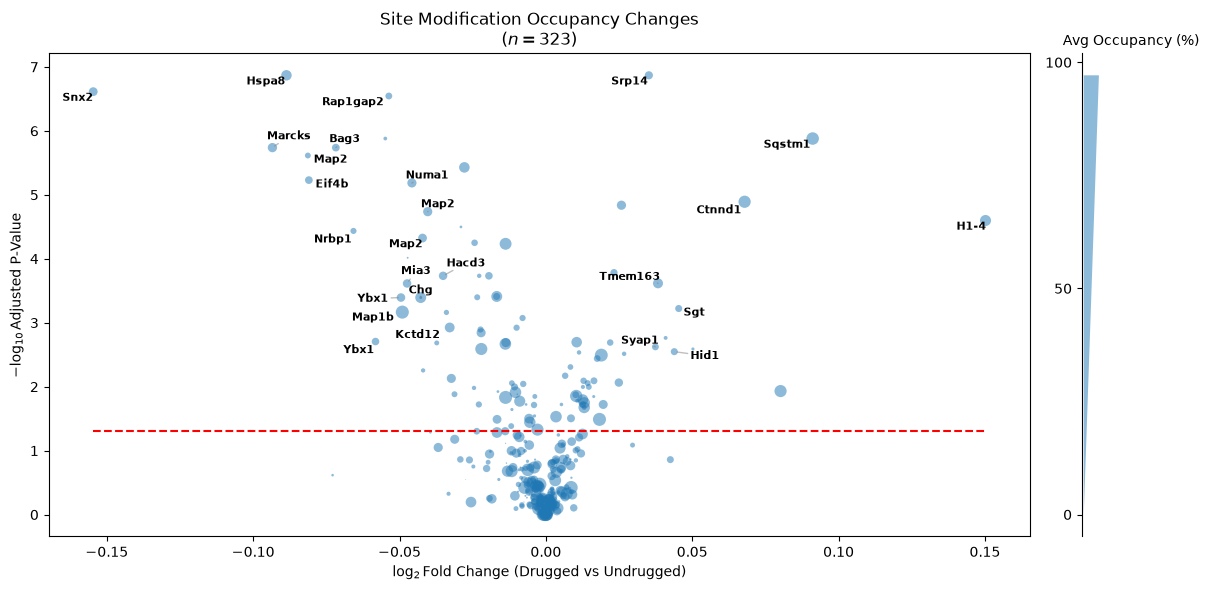

In [143]:
fig, [volcano, size_ax] = plt.subplots(1, 2, width_ratios=(1, 0.1), figsize=(12, 6))

s = raw_occupancies.mean(axis=1) * 100 # scale mean occupancy to percentage for marker size
max_s = max(s)

volcano.scatter(results["logFC"], 
            -np.log10(results["adj.P.Val"]), 
            alpha=0.5, s=s.values, edgecolors="none", zorder=1)

# Re-index s positionally against results to avoid pandas index misalignment
s_aligned = pd.Series(s.values, index=results.index)

points_to_label = results[
    (results["adj.P.Val"] <= 0.005) & (abs(results["logFC"]) >= 0.03) & (s_aligned > 15)
]

texts = []
for _, row in points_to_label.iterrows():
    texts.append(volcano.text(
        row["logFC"], -np.log10(row["adj.P.Val"]),
        row.ID.split("_")[-1], fontsize=8, fontweight="bold", ha="center", va="center", zorder=2
    ))

adjust_text(
    texts,
    x=results["logFC"].values,
    y=(-np.log10(results["adj.P.Val"])).values,
    ax=volcano,
    arrowprops=dict(arrowstyle="-", color="gray", lw=1, alpha=0.5)
)

volcano.hlines(-np.log10(0.05), 
           xmin=results["logFC"].min(), 
           xmax=results["logFC"].max(), 
           color="red", 
           linestyle="--", zorder=1)

volcano.set_xlabel("$\\log_2 \\text{Fold Change (Drugged vs Undrugged)}$")
volcano.set_ylabel("$-\\log_{10} \\text{Adjusted P-Value}$")
volcano.set_title(f"Site Modification Occupancy Changes\n($n={results.shape[0]}$)")

# Size legend bar — draw and compute layout first so window extents are accurate
size_ax.fill_betweenx([0, max_s], [0, max_s], alpha=0.5)
size_ax.get_xaxis().set_visible(False)
size_ax.get_yaxis().set_ticks([0, 50, 100])
for where, spine in size_ax.spines.items():
    spine.set_visible(where == "left")

plt.tight_layout()
fig.canvas.draw()
renderer = fig.canvas.get_renderer()

# Match xlim so the bar's max width equals the largest scatter marker's diameter in display space
size_ax_width_px = size_ax.get_window_extent(renderer).width
largest_diam_pts = 2 * np.sqrt(max_s / np.pi)          # scatter s is in pts², diameter in pts
largest_diam_px = largest_diam_pts * renderer.dpi / 72  # convert pts → display pixels
xlim_max = max_s * size_ax_width_px / largest_diam_px
size_ax.set_xlim(-xlim_max/50, xlim_max)
size_ax.set_title("Avg Occupancy (%)", fontsize=10)
plt.savefig(f"C:\\Users\\student\\Desktop\\Islets\\site_modification_occupancy_volcano_{run_suffix}.png", dpi=300)
plt.show()


In [144]:
output_df.index = output_df["Accession"] + "_" + output_df["Position"].astype(str) + "_" + output_df["Modification"] + "_" + output_df["Gene Name"].str.split(',').str[0].str.strip("primary:")
results.index = results["ID"]
joined = output_df.join(results, how="right").reset_index(drop=True)

logFC_threshold = 0.03
adjPVal_threshold = 0.005
print(f"Site modifications with logFC >= {logFC_threshold} and adj.P.Val <= {adjPVal_threshold}:")

(joined[(joined["logFC"] >= 0.03) & (joined["adj.P.Val"] <= 0.005)]
 .sort_values(["logFC","adj.P.Val"], ascending=[False, True])
 .head(20)[["Modification", "Accession", "Position", "Gene Name", "logFC", "adj.P.Val"]]
 .apply(lambda x: f"{x['Modification']} at {x['Gene Name'].split(',')[0].strip('primary:')} ({x['Accession']}:{x['Position']}) [logFC: {x['logFC']:.2f}, adj.P.Val: {x['adj.P.Val']:.3e}] ", axis=1)
 .tolist()
)

Site modifications with logFC >= 0.03 and adj.P.Val <= 0.005:


['Phosphoserine on S at H1-4 (P43274:36) [logFC: 0.15, adj.P.Val: 2.522e-05] ',
 'Phosphoserine on S at Sqstm1 (Q64337:24) [logFC: 0.09, adj.P.Val: 1.319e-06] ',
 'Phosphoserine on S at Ctnnd1 (P30999:864) [logFC: 0.07, adj.P.Val: 1.284e-05] ',
 'Hydroxylation on P at Pebp1 (P70296:11) [logFC: 0.05, adj.P.Val: 2.573e-03] ',
 'Phosphoserine on S at Sgt (Q8BJU0:307) [logFC: 0.05, adj.P.Val: 5.994e-04] ',
 'Phosphoserine on S at Hid1 (Q8R1F6:593) [logFC: 0.04, adj.P.Val: 2.833e-03] ',
 'Phosphoserine on S at Slk (O54988:647) [logFC: 0.04, adj.P.Val: 1.727e-03] ',
 'Phosphoserine on S at Tmem163 (Q8C996:45) [logFC: 0.04, adj.P.Val: 2.419e-04] ',
 'Phosphoserine on S at Syap1 (Q9D5V6:283) [logFC: 0.04, adj.P.Val: 2.385e-03] ',
 'Phosphoserine on S at Srp14 (P16254:45) [logFC: 0.04, adj.P.Val: 1.353e-07] ']

In [145]:
(joined
 .sort_values(["Accession", "Position", "Modification"])
 .reset_index(drop=True)
 .to_csv(f"C:\\Users\\student\\Desktop\\Islets\\site_modification_occupancy_quant_and_stats_{run_suffix}.tsv", index=False, sep="\t")
)